In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve, 
    average_precision_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay, 
    precision_recall_curve
)
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

In [2]:
# Load CSV
df_raw = pd.read_csv("investments_VC.csv", encoding="latin1")

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (54294, 39)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Inspect raw columns, types, and missing values
print("Column names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values:")
print(df_raw.isnull().sum().sort_values(ascending=False))

Column names:
['permalink', 'name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

Data types:
permalink                object
name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float64
founded_at         

In [4]:
# Clean column names
df = df_raw.copy()

# Strip whitespace from column names
df.columns = [col.strip() for col in df.columns]

print(df.columns.tolist())

['permalink', 'name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


In [5]:
# Clean all object columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace("nan", np.nan)

# Change funding column from string to float
df["funding_total_usd"] = (
    df["funding_total_usd"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["funding_total_usd"] = df["funding_total_usd"].replace({"": np.nan})
df["funding_total_usd"] = pd.to_numeric(df["funding_total_usd"], errors="coerce")

df["funding_total_usd"].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

In [6]:
# Convert date columns
date_cols = ["founded_at", "first_funding_at", "last_funding_at"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [7]:
# Drop rows where status is missing
df = df[df["status"].notna()].copy()

print("Remaining rows after dropping missing status:", df.shape)

# Check values
print(df["status"].value_counts())

# Keep only relevant statuses
valid_statuses = ["acquired", "closed", "operating"]
df = df[df["status"].isin(valid_statuses)].copy()

# Create binary target
df["success"] = np.where(df["status"] == "acquired", 1, 0)

df["success"].value_counts()

Remaining rows after dropping missing status: (48124, 39)
status
operating    41829
acquired      3692
closed        2603
Name: count, dtype: int64


success
0    44432
1     3692
Name: count, dtype: int64

In [8]:
# store original row count
rows_before = df.shape[0]

# drop rows where too many values are missing
threshold = int(0.7 * len(df.columns))  # keep rows with at least 70% non-null values
df = df.dropna(thresh=threshold)

# store new row count
rows_after = df.shape[0]

# print results
print("Shape after dropping sparse rows:", df.shape)
print(f"Rows dropped: {rows_before - rows_after}")
print(f"Percentage dropped: {(rows_before - rows_after) / rows_before:.2%}")

Shape after dropping sparse rows: (48123, 40)
Rows dropped: 1
Percentage dropped: 0.00%


In [9]:
# store row count before removing duplicates
rows_before = df.shape[0]

# count duplicates based on permalink
duplicate_count = df["permalink"].duplicated().sum()

print(f"Number of duplicate rows based on permalink: {duplicate_count}")

# drop duplicate startups (keep first occurrence)
df = df.drop_duplicates(subset="permalink")

# store row count after
rows_after = df.shape[0]

print("Shape after dropping duplicates:", df.shape)
print(f"Rows dropped: {rows_before - rows_after}")

Number of duplicate rows based on permalink: 2
Shape after dropping duplicates: (48121, 40)
Rows dropped: 2


In [10]:
# Fill missing values

# Label missing categorical values as "unknown"
categorical_cols = ["category_list", "market", "country_code", "state_code", "region", "city"]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

# Numeric columns -> fill missing values with 0 for funding-related
funding_cols = [
    "seed", "venture", "equity_crowdfunding", "undisclosed",
    "convertible_note", "debt_financing", "angel", "grant",
    "private_equity", "post_ipo_equity", "post_ipo_debt",
    "secondary_market", "product_crowdfunding",
    "round_A", "round_B", "round_C", "round_D",
    "round_E", "round_F", "round_G", "round_H",
    "funding_rounds"
]

for col in funding_cols:
    df[col] = df[col].fillna(0)

# Replace NA in total funding column and founded year with column median (important columns)
df["funding_total_usd"] = df["funding_total_usd"].fillna(df["funding_total_usd"].median())
df["founded_year"] = df["founded_year"].fillna(df["founded_year"].median())

In [11]:
# Feature engineering

# Apply log transformation to funding to make distribution more balanced
df["log_funding"] = np.log1p(df["funding_total_usd"])

# Startup age at first funding
df["startup_age_days"] = (df["first_funding_at"] - df["founded_at"]).dt.days

# Funding duration
df["funding_duration_days"] = (df["last_funding_at"] - df["first_funding_at"]).dt.days

# Fill engineered missing using column median
df["startup_age_days"] = df["startup_age_days"].fillna(df["startup_age_days"].median())
df["funding_duration_days"] = df["funding_duration_days"].fillna(df["funding_duration_days"].median())

In [12]:
# Dataset overview after cleaning
print("Final dataset shape:", df.shape)

print("\nClass distribution:")
print(df["success"].value_counts())

print("\nClass distribution (percent):")
print(df["success"].value_counts(normalize=True))

Final dataset shape: (48121, 43)

Class distribution:
success
0    44429
1     3692
Name: count, dtype: int64

Class distribution (percent):
success
0    0.923277
1    0.076723
Name: proportion, dtype: float64


# EXPLORATORY DATA ANALYSIS

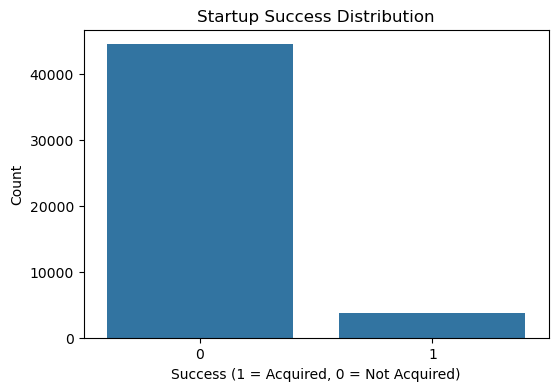

In [13]:
# Plot class distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="success")
plt.title("Startup Success Distribution")
plt.xlabel("Success (1 = Acquired, 0 = Not Acquired)")
plt.ylabel("Count")
plt.show()

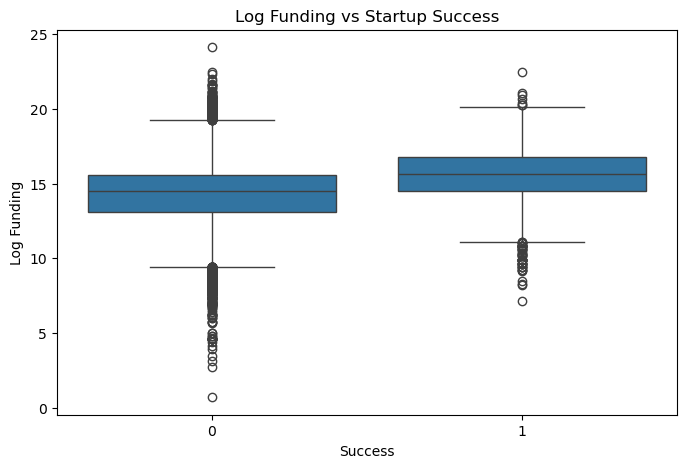

In [14]:
# Plot funding vs. success
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="success", y="log_funding")
plt.title("Log Funding vs Startup Success")
plt.xlabel("Success")
plt.ylabel("Log Funding")
plt.show()

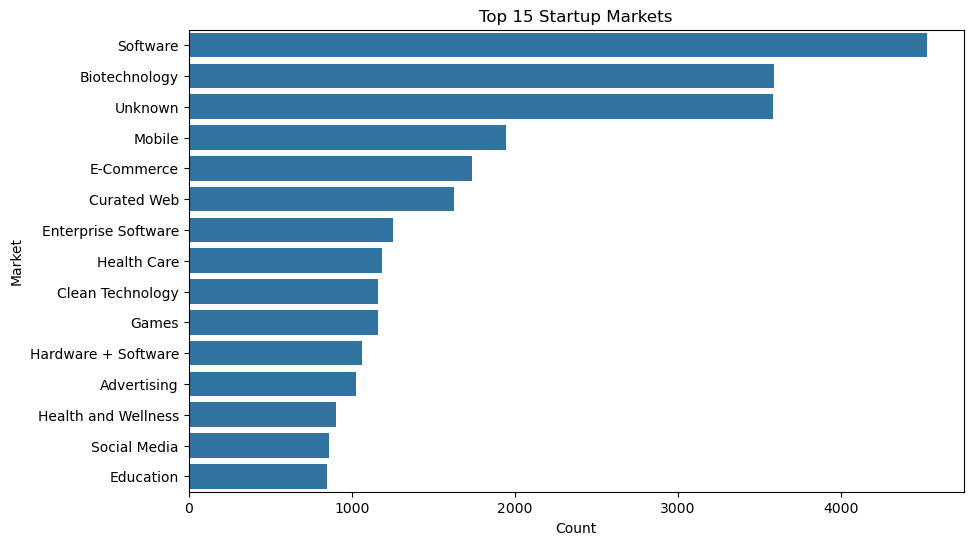

In [15]:
# Plot top industries and markets
top_markets = df["market"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_markets.values, y=top_markets.index)
plt.title("Top 15 Startup Markets")
plt.xlabel("Count")
plt.ylabel("Market")
plt.show()

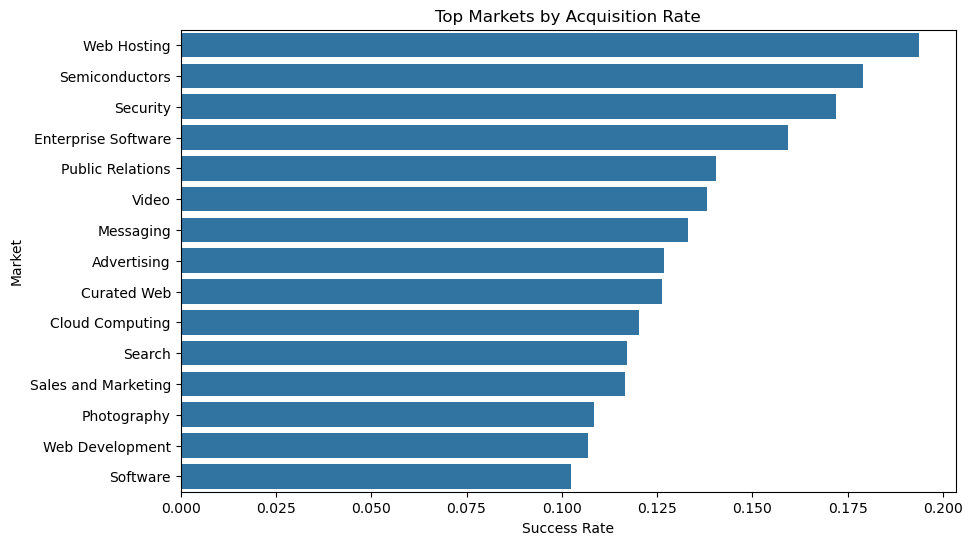

In [16]:
# Plot success rate by market
market_success = (
    df.groupby("market")["success"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)

# keep only markets with enough data
market_success = market_success[market_success["count"] >= 100]
market_success = market_success.sort_values("mean", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=market_success["mean"], y=market_success.index)
plt.title("Top Markets by Acquisition Rate")
plt.xlabel("Success Rate")
plt.ylabel("Market")
plt.show()

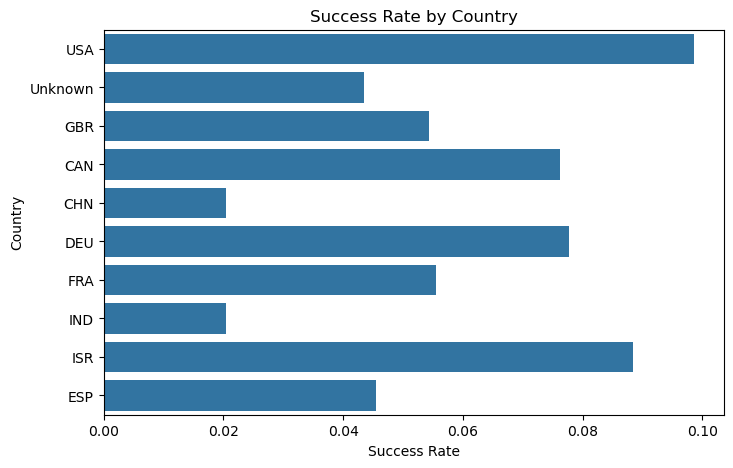

In [17]:
# Plot success rate by country
country_success = (
    df.groupby("country_code")["success"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)

country_success = country_success[country_success["count"] >= 100].head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=country_success["mean"], y=country_success.index)
plt.title("Success Rate by Country")
plt.xlabel("Success Rate")
plt.ylabel("Country")
plt.show()

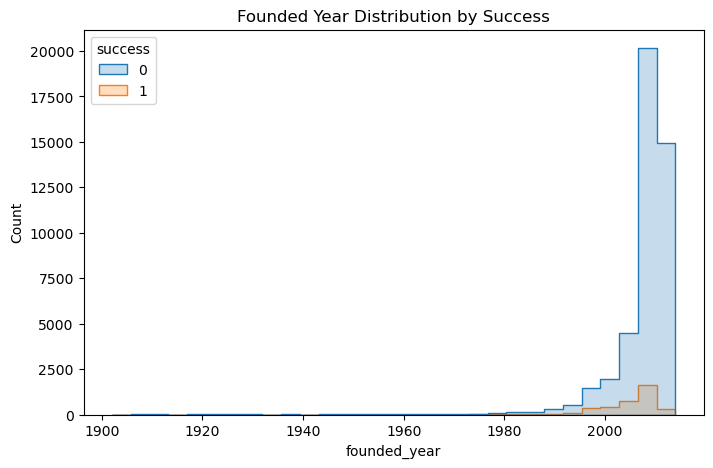

In [18]:
# Plot founding year vs. success
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="founded_year", hue="success", bins=30, element="step")
plt.title("Founded Year Distribution by Success")
plt.show()

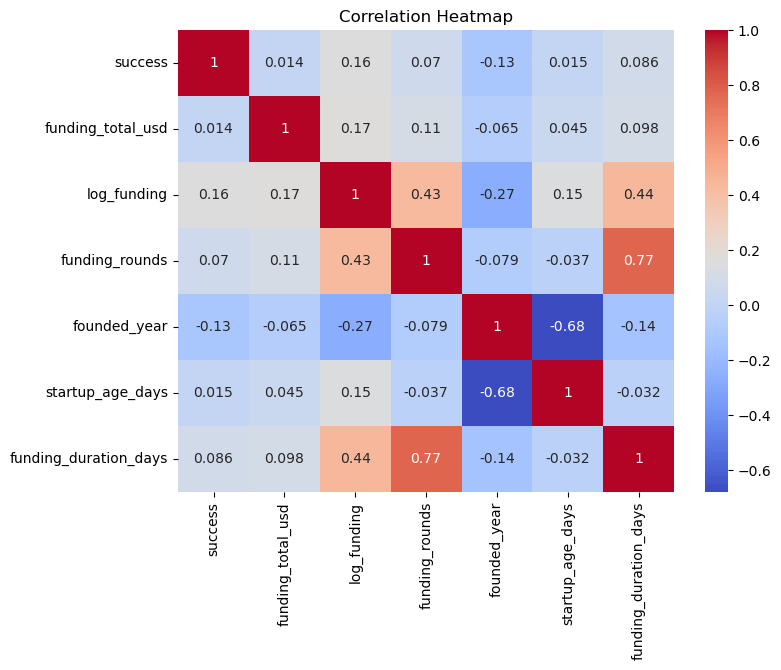

In [19]:
# Create correlation heatmap
numeric_cols = [
    "success", "funding_total_usd", "log_funding",
    "funding_rounds", "founded_year",
    "startup_age_days", "funding_duration_days"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Model 1: Logistic Regression

In [20]:
# Create a copy for modeling
model_df = df.copy()

# Extract a simpler single category from category_list
# Take just the first category to reduce dimensionality
model_df["primary_category"] = model_df["category_list"].str.split("|").str[0]

# Fill any remaining missing primary_category values
model_df["primary_category"] = model_df["primary_category"].fillna("Unknown")

# If founded_year became float from imputation, cast to int
model_df["founded_year"] = model_df["founded_year"].round().astype(int)

print("Modeling dataframe shape:", model_df.shape)
model_df.head()

Modeling dataframe shape: (48121, 44)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,round_D,round_E,round_F,round_G,round_H,success,log_funding,startup_age_days,funding_duration_days,primary_category
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,1,14.375127,29.0,0.0,
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0,15.201805,545.0,111.0,
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000.0,operating,EST,Unknown,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0,10.596660,-78.0,0.0,
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,Unknown,London,...,0.0,0.0,0.0,0.0,0.0,0,14.220976,0.0,0.0,
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0,11.002117,228.0,40.0,


In [21]:
# Target
y = model_df["success"]

# Features to drop:
drop_cols = [
    "success",
    "status",
    "permalink",
    "name",
    "homepage_url",
    "founded_at",
    "first_funding_at",
    "last_funding_at",
    "founded_month",
    "founded_quarter",
    "city",
    "region"
]

X = model_df.drop(columns=drop_cols, errors="ignore")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nColumns used for modeling:")
print(X.columns.tolist())

Feature matrix shape: (48121, 32)
Target shape: (48121,)

Columns used for modeling:
['category_list', 'market', 'funding_total_usd', 'country_code', 'state_code', 'funding_rounds', 'founded_year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H', 'log_funding', 'startup_age_days', 'funding_duration_days', 'primary_category']


In [22]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['funding_total_usd', 'funding_rounds', 'founded_year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H', 'log_funding', 'startup_age_days', 'funding_duration_days']

Categorical features:
['category_list', 'market', 'country_code', 'state_code', 'primary_category']


In [23]:
# Take smaller stratified sample (Logistic Regression could not handle full data set)
sample_size = 10000

X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=sample_size,
    stratify=y,
    random_state=42
)

print("Original X shape:", X.shape)
print("Sampled X shape:", X_sample.shape)

print("\nOriginal class distribution:")
print(y.value_counts(normalize=True))

print("\nSampled class distribution:")
print(y_sample.value_counts(normalize=True))

Original X shape: (48121, 32)
Sampled X shape: (10000, 32)

Original class distribution:
success
0    0.923277
1    0.076723
Name: proportion, dtype: float64

Sampled class distribution:
success
0    0.9233
1    0.0767
Name: proportion, dtype: float64


In [24]:
# Split into training and testing 
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (8000, 32)
X_test shape: (2000, 32)

Train class distribution:
success
0    0.92325
1    0.07675
Name: proportion, dtype: float64

Test class distribution:
success
0    0.9235
1    0.0765
Name: proportion, dtype: float64


In [25]:
# Numeric preprocessing (median imputation, z-score scaling)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing (fill missing with unknown, one-hot encode categories)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numeric + categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Logistic regression pipeline
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=10000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['funding_total_usd',
                                                   'funding_rounds',
                                                   'founded_year', 'seed',
                                                   'venture',
                                                   'equity_crowdfunding',
                                                   'undisclosed',
                                                   'convertible_note',
                                                   'debt_financing', 'angel',
                                                   'grant', 'private_equity',
                                                   'post_ipo_equ...
                                                   'startup_age_days',
                                                   'funding_duration_days']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['category_list', 'market',
                                                   'country_code', 'state_code',
                                                   'primary_category'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=10000,
                                    random_state=42))])

In [26]:
# Grid of hyperparameters
param_grid = [
    {
        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__solver": ["lbfgs"]
    },
    {
        "model__penalty": ["l1"],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__solver": ["saga"]
    }
]

# Stratified CV because the classes are imbalanced
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",   # primary metric
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validated ROC-AUC:")
print(grid_search.best_score_)

Fitting 5 folds for each of 11 candidates, totalling 55 fits
Best parameters:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Best cross-validated ROC-AUC:
0.8000571986398619


Test ROC-AUC: 0.780667112540739
Test PR-AUC: 0.21259528559493424
Test F1: 0.2971768202080238

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.77      0.86      1847
           1       0.19      0.65      0.30       153

    accuracy                           0.76      2000
   macro avg       0.58      0.71      0.58      2000
weighted avg       0.91      0.76      0.81      2000



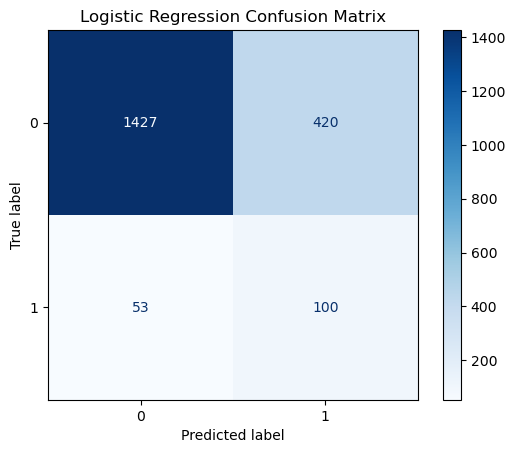

In [27]:
# Best fitted model
best_logreg = grid_search.best_estimator_

# Predictions
y_pred = best_logreg.predict(X_test)
y_prob = best_logreg.predict_proba(X_test)[:, 1]

# Metrics
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print("Test ROC-AUC:", roc_auc)
print("Test PR-AUC:", pr_auc)
print("Test F1:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

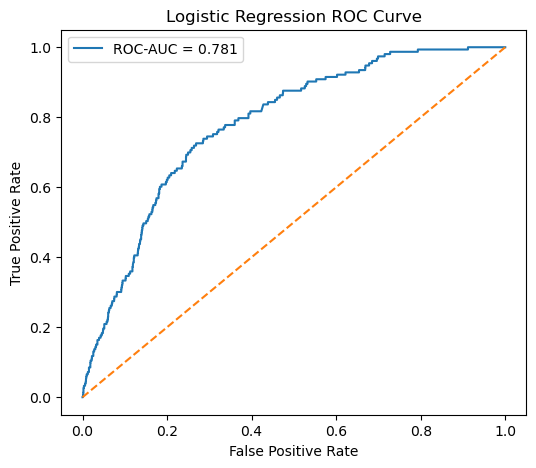

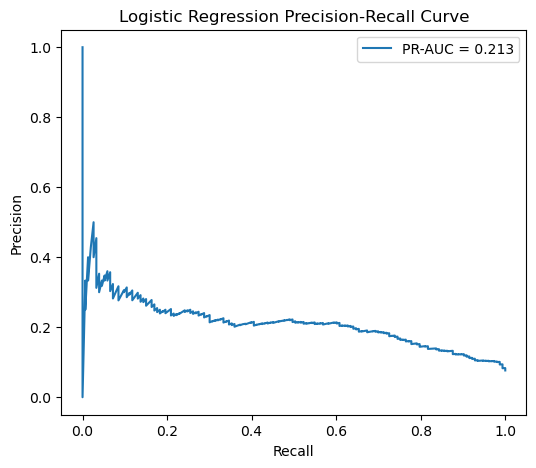

In [28]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression Precision-Recall Curve")
plt.legend()
plt.show()

In [29]:
# Get feature names after preprocessing
feature_names = best_logreg.named_steps["preprocessor"].get_feature_names_out()

# Get logistic regression coefficients
coefficients = best_logreg.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
}).sort_values("abs_coefficient", ascending=False)

print("Top 20 most important coefficients:")
display(coef_df.head(20))

Top 20 most important coefficients:


,feature,coefficient,abs_coefficient
2,num__founded_year,-0.995505,0.995505
25,num__startup_age_days,-0.950654,0.950654
24,num__log_funding,0.837024,0.837024
3481,cat__market_Health and Wellness,-0.814661,0.814661
3896,cat__state_code_MD,0.791989,0.791989
10,num__grant,-0.787893,0.787893
3879,cat__state_code_CA,0.785608,0.785608
319,cat__category_list_|Biotechnology|,-0.730297,0.730297
3870,cat__country_code_Unknown,0.726370,0.726370
3375,cat__market_Curated Web,0.720175,0.720175


In [30]:
# Show strongest positive and negative predictors
top_positive = coef_df.sort_values("coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(10)

print("Top positive predictors of startup success:")
display(top_positive[["feature", "coefficient"]])

print("Top negative predictors of startup success:")
display(top_negative[["feature", "coefficient"]])

Top positive predictors of startup success:


,feature,coefficient
24,num__log_funding,0.837024
3896,cat__state_code_MD,0.791989
3879,cat__state_code_CA,0.785608
3870,cat__country_code_Unknown,0.726370
3375,cat__market_Curated Web,0.720175
3908,cat__state_code_NJ,0.693518
1125,cat__category_list_|Finance|Curated Web|,0.622395
3767,cat__market_Video Streaming,0.618803
3779,cat__market_Web Development,0.586469
3916,cat__state_code_ON,0.586410


Top negative predictors of startup success:


,feature,coefficient
2,num__founded_year,-0.995505
25,num__startup_age_days,-0.950654
3481,cat__market_Health and Wellness,-0.814661
10,num__grant,-0.787893
319,cat__category_list_|Biotechnology|,-0.730297
3804,cat__country_code_CHN,-0.651374
3748,cat__market_Transportation,-0.589765
3658,cat__market_Real Estate,-0.578516
12,num__post_ipo_equity,-0.552882
1331,cat__category_list_|Health and Wellness|,-0.524482


Linear Discriminant Analysis

In [31]:
# Use only numeric features for LDA
X_lda = model_df[numeric_features].copy()
y_lda = model_df["success"]

print("LDA feature shape:", X_lda.shape)

LDA feature shape: (48121, 27)


In [32]:
# Split training and testing 
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
    X_lda, y_lda,
    test_size=0.2,
    stratify=y_lda,
    random_state=42
)

# Power transform & scale features
power = PowerTransformer()
scaler = StandardScaler()

X_train_lda = power.fit_transform(X_train_lda)
X_test_lda = power.transform(X_test_lda)

X_train_lda = scaler.fit_transform(X_train_lda)
X_test_lda = scaler.transform(X_test_lda)

# Oversample minority class (improve recall)
smote = SMOTE(random_state=42)
X_train_lda, y_train_lda = smote.fit_resample(X_train_lda, y_train_lda)

/Users/loreleiduarte/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/Users/loreleiduarte/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


In [33]:
# Train LDA
lda = LinearDiscriminantAnalysis(
    solver="lsqr",
    shrinkage="auto"
)

lda.fit(X_train_lda, y_train_lda)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [34]:
# Predictions
y_pred_lda = lda.predict(X_test_lda)
y_prob_lda = lda.predict_proba(X_test_lda)[:, 1]

# Try different thresholds for best F1
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred_lda = (y_prob_lda >= threshold).astype(int)

LDA ROC-AUC: 0.7602589635663431
LDA PR-AUC: 0.19158671277809725
LDA F1: 0.2663731425426527

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      8887
           1       0.17      0.66      0.27       738

    accuracy                           0.72      9625
   macro avg       0.56      0.69      0.55      9625
weighted avg       0.90      0.72      0.79      9625



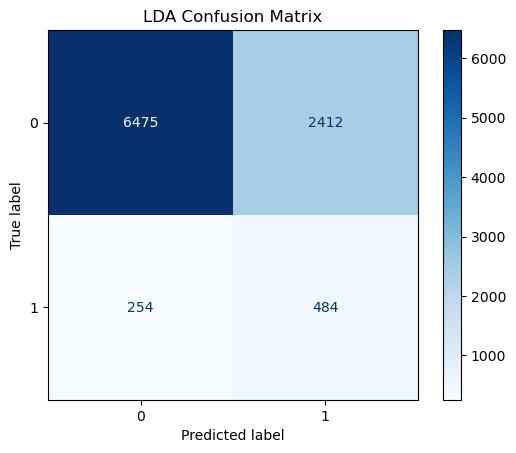

In [35]:
# Evaluate LDA
roc_auc_lda = roc_auc_score(y_test_lda, y_prob_lda)
pr_auc_lda = average_precision_score(y_test_lda, y_prob_lda)
f1_lda = f1_score(y_test_lda, y_pred_lda)

print("LDA ROC-AUC:", roc_auc_lda)
print("LDA PR-AUC:", pr_auc_lda)
print("LDA F1:", f1_lda)

print("\nClassification Report:")
print(classification_report(y_test_lda, y_pred_lda))

# Confusion matrix
cm = confusion_matrix(y_test_lda, y_pred_lda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("LDA Confusion Matrix")
plt.show()

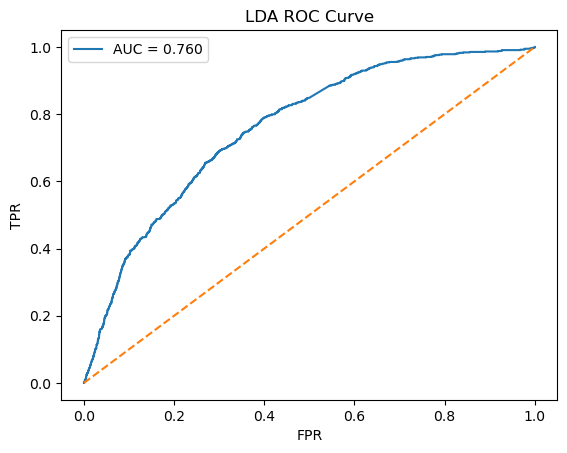

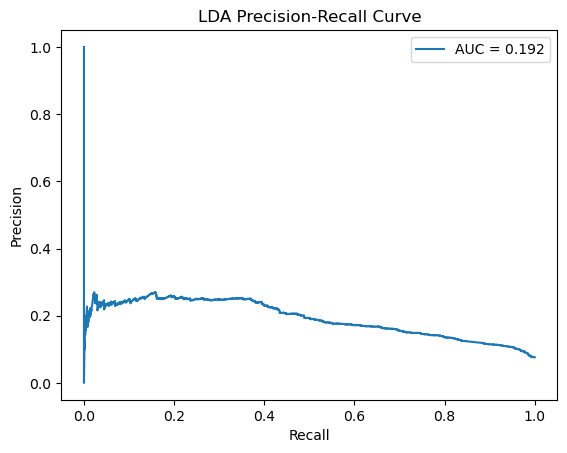

In [36]:
# Generate ROC curve
fpr, tpr, _ = roc_curve(y_test_lda, y_prob_lda)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_lda:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("LDA ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# Generate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_lda, y_prob_lda)

plt.figure()
plt.plot(recall, precision, label=f"AUC = {pr_auc_lda:.3f}")
plt.title("LDA Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

K-nearest neighbors

In [37]:
# Take a representative sample of data
sample_size = 10000

X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=sample_size,
    stratify=y,
    random_state=42
)

In [38]:
# Split training and testing 
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_sample, y_sample,
    test_size=0.2,
    stratify=y_sample,
    random_state=42
)

In [39]:
# Build preprocessing + kNN pipeline

# Reuse feature lists
numeric_features = X_train_knn.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_knn.select_dtypes(include=["object", "category"]).columns.tolist()

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("pca", PCA()),
    ("model", KNeighborsClassifier())
])

In [40]:
# Hyperparameter tuning
param_grid = {
    "pca__n_components": [10, 20, 30, 40],
    "model__n_neighbors": [5, 10, 15, 25],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_knn = GridSearchCV(
    knn_pipeline,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_train_knn, y_train_knn)

print("Best parameters:", grid_search_knn.best_params_)
print("Best CV ROC-AUC:", grid_search_knn.best_score_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 25, 'model__weights': 'distance', 'pca__n_components': 30}
Best CV ROC-AUC: 0.7364983307985795


kNN ROC-AUC: 0.7258635271470076
kNN PR-AUC: 0.20353883813470622
kNN F1: 0.025157232704402517

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1847
           1       0.33      0.01      0.03       153

    accuracy                           0.92      2000
   macro avg       0.63      0.51      0.49      2000
weighted avg       0.88      0.92      0.89      2000



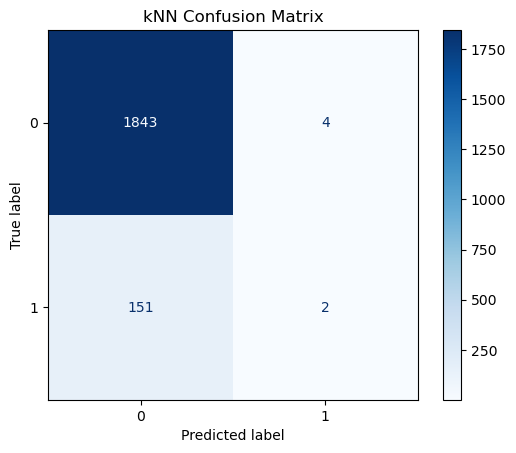

In [41]:
# Evaluate kNN
best_knn = grid_search_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test_knn)
y_prob_knn = best_knn.predict_proba(X_test_knn)[:, 1]

print("kNN ROC-AUC:", roc_auc_score(y_test_knn, y_prob_knn))
print("kNN PR-AUC:", average_precision_score(y_test_knn, y_prob_knn))
print("kNN F1:", f1_score(y_test_knn, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test_knn, y_pred_knn))

# confusion matrix
cm = confusion_matrix(y_test_knn, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("kNN Confusion Matrix")
plt.show()

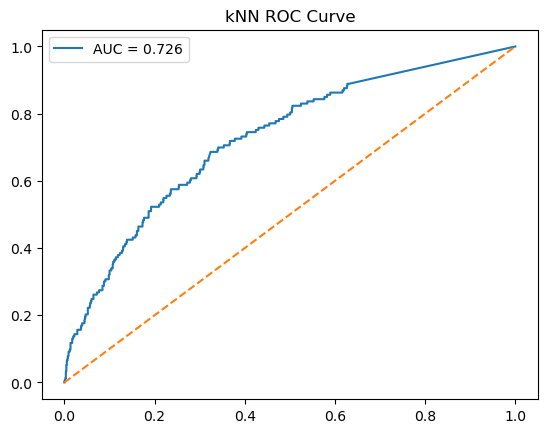

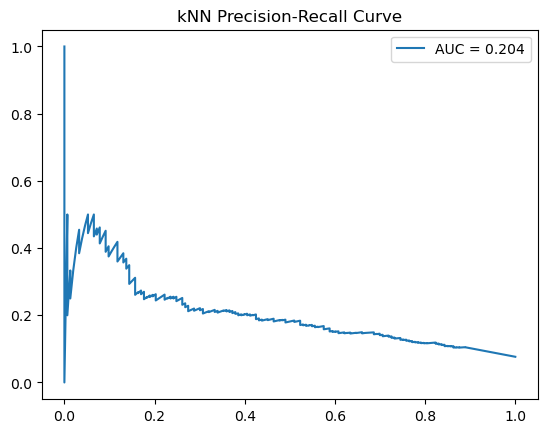

In [42]:
# Generate ROC curve
fpr, tpr, _ = roc_curve(y_test_knn, y_prob_knn)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_knn, y_prob_knn):.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("kNN ROC Curve")
plt.legend()
plt.show()

# Generate Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test_knn, y_prob_knn)

plt.figure()
plt.plot(recall, precision, label=f"AUC = {average_precision_score(y_test_knn, y_prob_knn):.3f}")
plt.title("kNN Precision-Recall Curve")
plt.legend()
plt.show()